# Метод главных компонент

Исследуем корреляции, определим необходимое число компонент для сохранения 95% дисперсии, проверим качество классификации и визуализируем объекты в пространстве первых двух компонент.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")

## Данные и корреляции

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


Размер: (178, 13)
Классы: {0: 59, 1: 71, 2: 48}


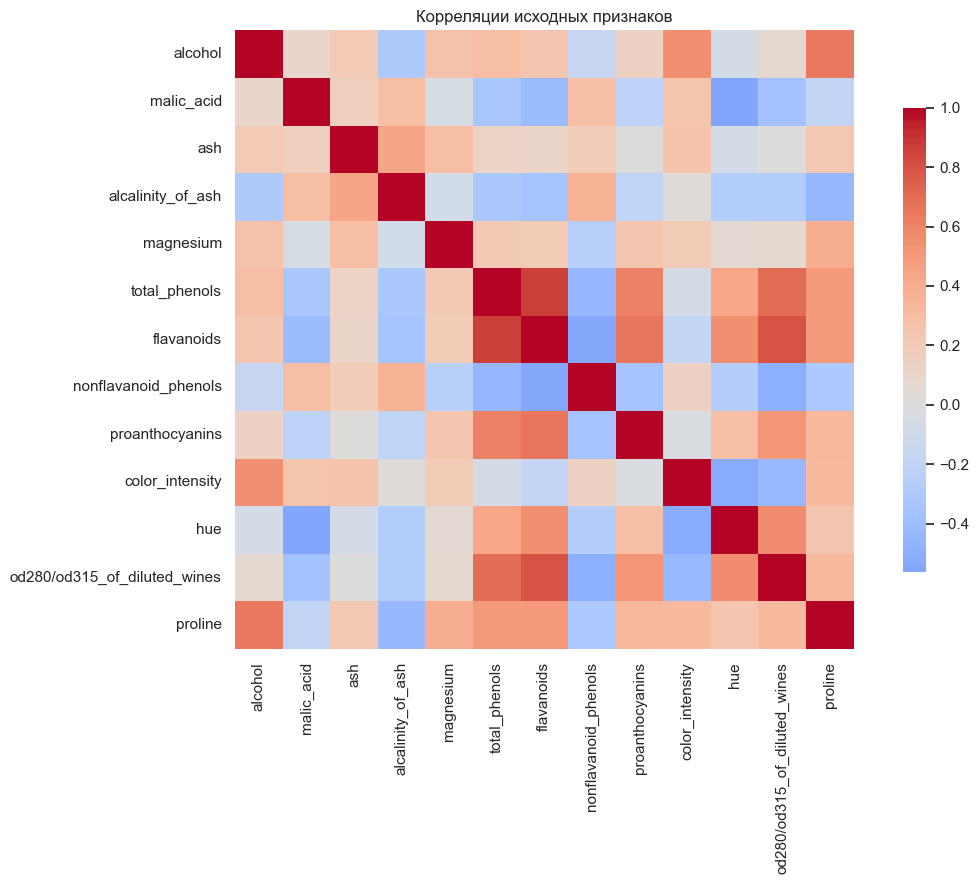

In [2]:
dataset = load_wine(as_frame=True)
features = dataset.data
target = dataset.target

display(features.head())
print("Размер:", features.shape)
print("Классы:", target.value_counts().sort_index().to_dict())

plt.figure(figsize=(12, 9))
sns.heatmap(features.corr(), cmap="coolwarm", center=0, square=True, cbar_kws={"shrink": 0.75})
plt.title("Корреляции исходных признаков")
plt.tight_layout()
plt.show()

## Объяснённая дисперсия

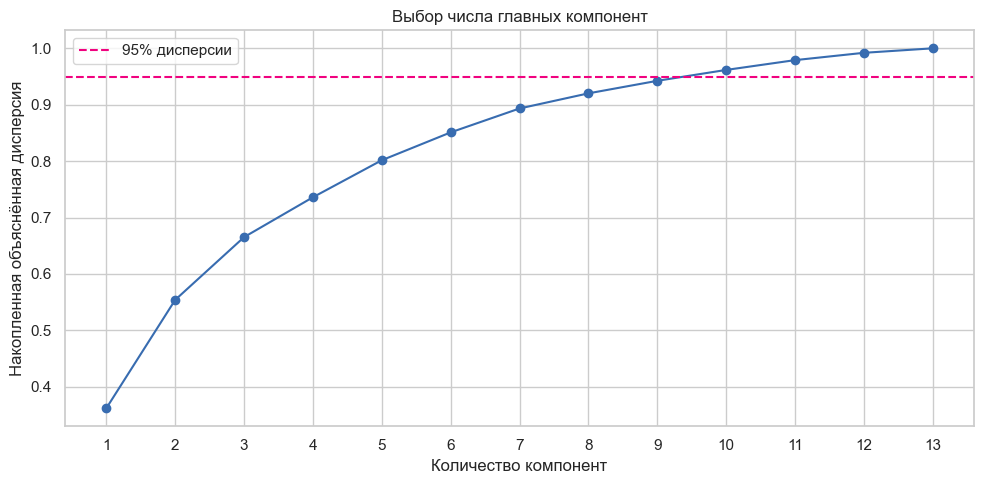

In [3]:
scaled_features = StandardScaler().fit_transform(features)
full_pca = PCA().fit(scaled_features)
cumulative_variance = np.cumsum(full_pca.explained_variance_ratio_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker="o", color="#386cb0")
plt.axhline(0.95, linestyle="--", color="#f0027f", label="95% дисперсии")
plt.xlabel("Количество компонент")
plt.ylabel("Накопленная объяснённая дисперсия")
plt.title("Выбор числа главных компонент")
plt.xticks(range(1, len(cumulative_variance) + 1))
plt.legend()
plt.tight_layout()
plt.show()

## PCA и классификация

In [4]:
train_features, test_features, train_target, test_target = train_test_split(
    features, target, test_size=0.25, random_state=42, stratify=target
)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95, svd_solver="full")),
    ("model", LogisticRegression(max_iter=3000, random_state=42)),
])
pipeline.fit(train_features, train_target)
prediction = pipeline.predict(test_features)
pca = pipeline.named_steps["pca"]

pd.Series({
    "source_features": features.shape[1],
    "selected_components": pca.n_components_,
    "explained_variance": pca.explained_variance_ratio_.sum(),
    "accuracy": accuracy_score(test_target, prediction),
}).to_frame("value")

,value
source_features,13.000000
selected_components,10.000000
explained_variance,0.963720
accuracy,0.977778


## Двумерная проекция

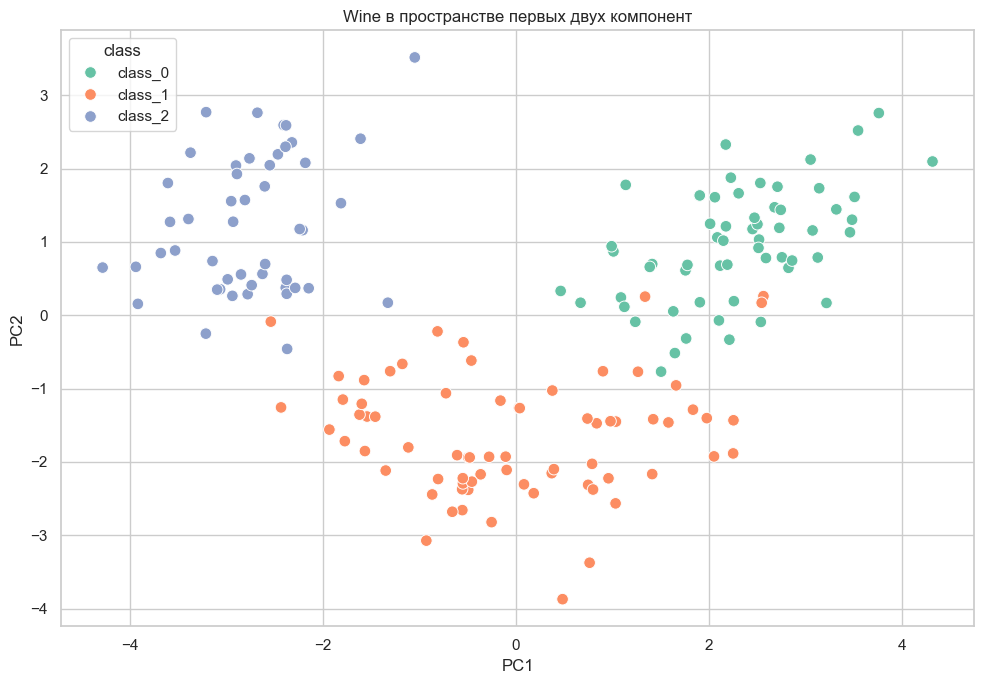

In [5]:
pca_2 = PCA(n_components=2)
projection = pca_2.fit_transform(scaled_features)
projection_frame = pd.DataFrame({
    "PC1": projection[:, 0],
    "PC2": projection[:, 1],
    "class": target.map(dict(enumerate(dataset.target_names))),
})

plt.figure(figsize=(10, 7))
sns.scatterplot(data=projection_frame, x="PC1", y="PC2", hue="class", palette="Set2", s=70)
plt.title("Wine в пространстве первых двух компонент")
plt.tight_layout()
plt.show()

## Вклад признаков в первые компоненты

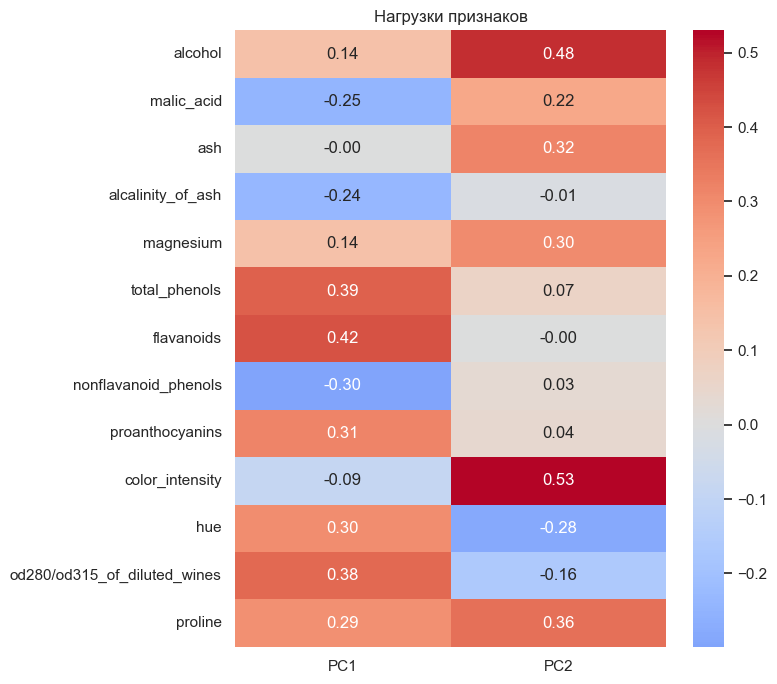

In [6]:
loadings = pd.DataFrame(
    pca_2.components_.T,
    index=features.columns,
    columns=["PC1", "PC2"],
)

plt.figure(figsize=(8, 7))
sns.heatmap(loadings, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Нагрузки признаков")
plt.tight_layout()
plt.show()

## Вывод

PCA заменяет исходные коррелирующие признаки меньшим числом ортогональных компонент. Накопленная дисперсия помогает выбрать размерность, двумерная проекция показывает разделимость классов, а нагрузки объясняют вклад исходных признаков.

## Расширенный анализ PCA

In [7]:
from sklearn.model_selection import StratifiedKFold, cross_validate

### Влияние масштабирования

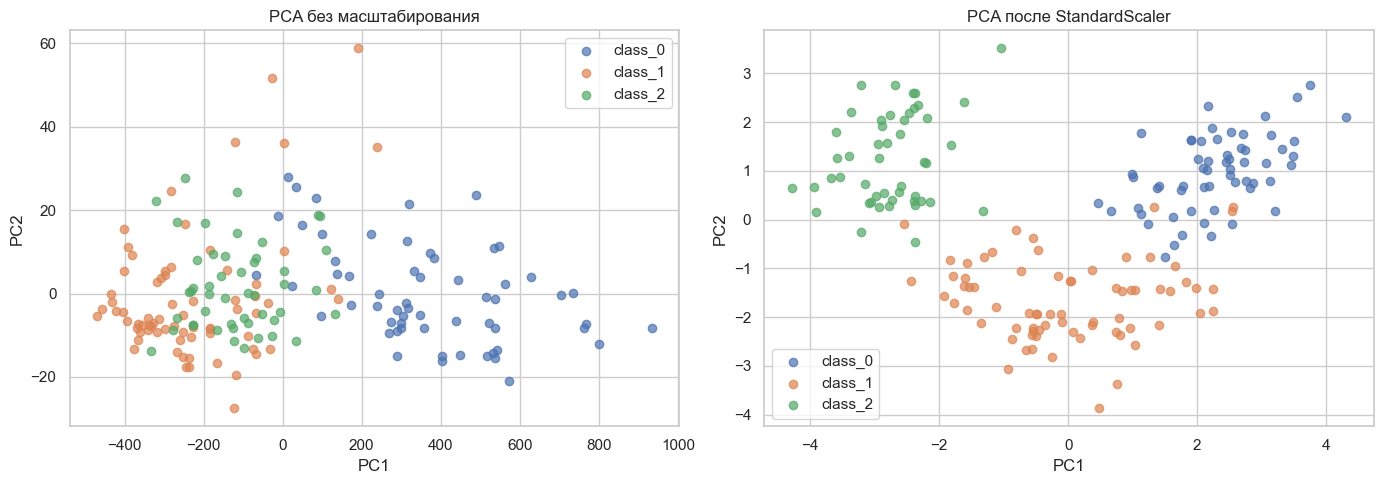

In [8]:
unscaled_projection = PCA(n_components=2).fit_transform(features)
scaled_projection = PCA(n_components=2).fit_transform(scaled_features)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for class_index, class_name in enumerate(dataset.target_names):
    mask = target == class_index
    axes[0].scatter(unscaled_projection[mask, 0], unscaled_projection[mask, 1], label=class_name, alpha=0.7)
    axes[1].scatter(scaled_projection[mask, 0], scaled_projection[mask, 1], label=class_name, alpha=0.7)
axes[0].set_title("PCA без масштабирования")
axes[1].set_title("PCA после StandardScaler")
for axis in axes:
    axis.set_xlabel("PC1")
    axis.set_ylabel("PC2")
    axis.legend()
plt.tight_layout()
plt.show()

### Scree plot

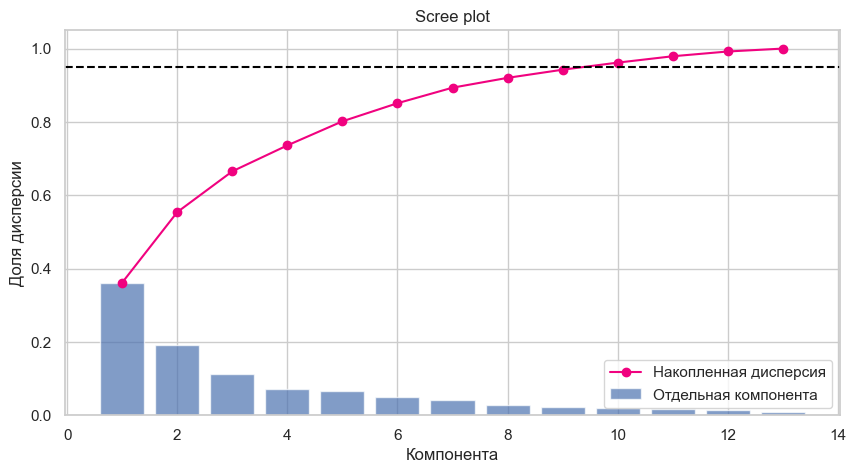

In [9]:
fig, axis = plt.subplots(figsize=(10, 5))
components = np.arange(1, len(full_pca.explained_variance_ratio_) + 1)
axis.bar(components, full_pca.explained_variance_ratio_, alpha=0.7, label="Отдельная компонента")
axis.plot(components, cumulative_variance, marker="o", color="#f0027f", label="Накопленная дисперсия")
axis.axhline(0.95, linestyle="--", color="black")
axis.set_title("Scree plot")
axis.set_xlabel("Компонента")
axis.set_ylabel("Доля дисперсии")
axis.legend()
plt.show()

### Ошибка реконструкции

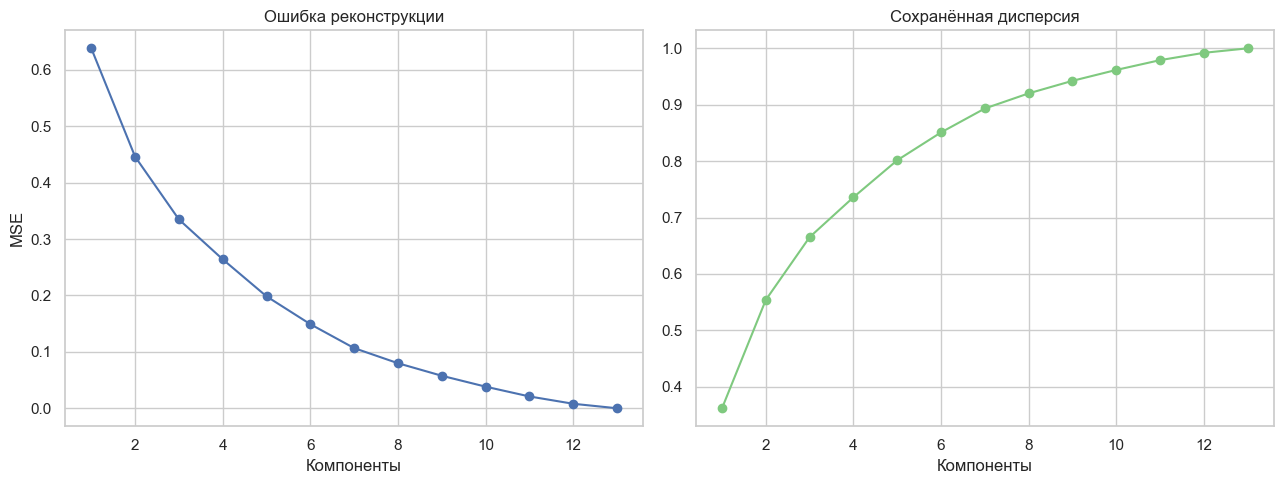

In [10]:
reconstruction_rows = []
for components_count in range(1, features.shape[1] + 1):
    candidate = PCA(n_components=components_count).fit(scaled_features)
    reconstructed = candidate.inverse_transform(candidate.transform(scaled_features))
    reconstruction_rows.append({
        "components": components_count,
        "mse": np.mean((scaled_features - reconstructed) ** 2),
        "variance": candidate.explained_variance_ratio_.sum(),
    })

reconstruction = pd.DataFrame(reconstruction_rows)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(reconstruction["components"], reconstruction["mse"], marker="o")
axes[0].set_title("Ошибка реконструкции")
axes[0].set_xlabel("Компоненты")
axes[0].set_ylabel("MSE")
axes[1].plot(reconstruction["components"], reconstruction["variance"], marker="o", color="#7fc97f")
axes[1].set_title("Сохранённая дисперсия")
axes[1].set_xlabel("Компоненты")
plt.tight_layout()
plt.show()

### Качество классификации с PCA и без PCA

,model,accuracy_mean,accuracy_std
0,Without PCA,0.983297,0.019293
1,PCA 95%,0.983297,0.019293
2,PCA 2 components,0.960659,0.021394


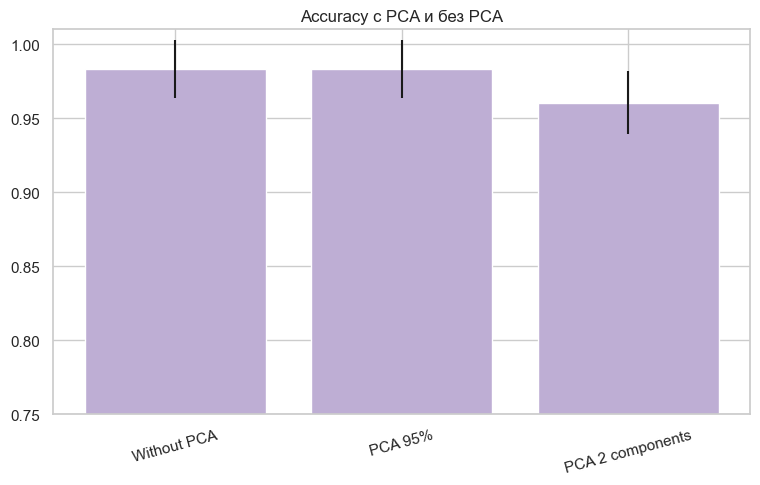

In [11]:
validation = StratifiedKFold(n_splits=7, shuffle=True, random_state=42)
comparison_models = {
    "Without PCA": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=3000, random_state=42)),
    ]),
    "PCA 95%": Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.95)),
        ("model", LogisticRegression(max_iter=3000, random_state=42)),
    ]),
    "PCA 2 components": Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=2)),
        ("model", LogisticRegression(max_iter=3000, random_state=42)),
    ]),
}

comparison_rows = []
for name, estimator in comparison_models.items():
    scores = cross_validate(estimator, features, target, cv=validation, scoring="accuracy")
    comparison_rows.append({"model": name, "accuracy_mean": scores["test_score"].mean(), "accuracy_std": scores["test_score"].std()})

classification_comparison = pd.DataFrame(comparison_rows)
display(classification_comparison)

plt.figure(figsize=(9, 5))
plt.bar(classification_comparison["model"], classification_comparison["accuracy_mean"], yerr=classification_comparison["accuracy_std"], color="#beaed4")
plt.ylim(0.75, 1.01)
plt.title("Accuracy с PCA и без PCA")
plt.xticks(rotation=15)
plt.show()

### Центры классов в пространстве PCA

,PC1,PC2
class,,
class_0,2.282739,0.967874
class_1,-0.038986,-1.643483
class_2,-2.748200,1.241308


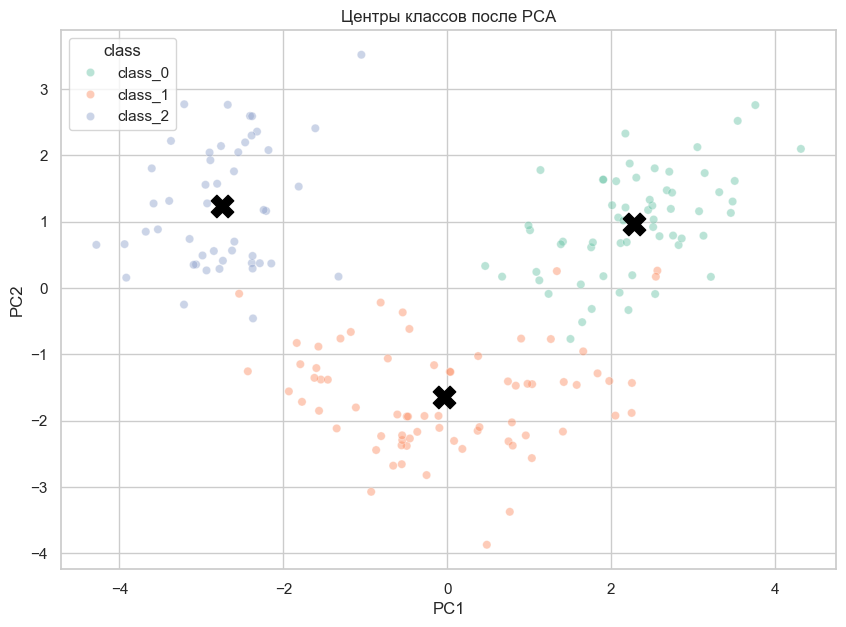

In [12]:
class_centers = projection_frame.groupby("class")[["PC1", "PC2"]].mean()
display(class_centers)

plt.figure(figsize=(10, 7))
sns.scatterplot(data=projection_frame, x="PC1", y="PC2", hue="class", palette="Set2", alpha=0.45)
plt.scatter(class_centers["PC1"], class_centers["PC2"], marker="X", s=260, color="black", label="Центры классов")
plt.title("Центры классов после PCA")
plt.show()

### Biplot

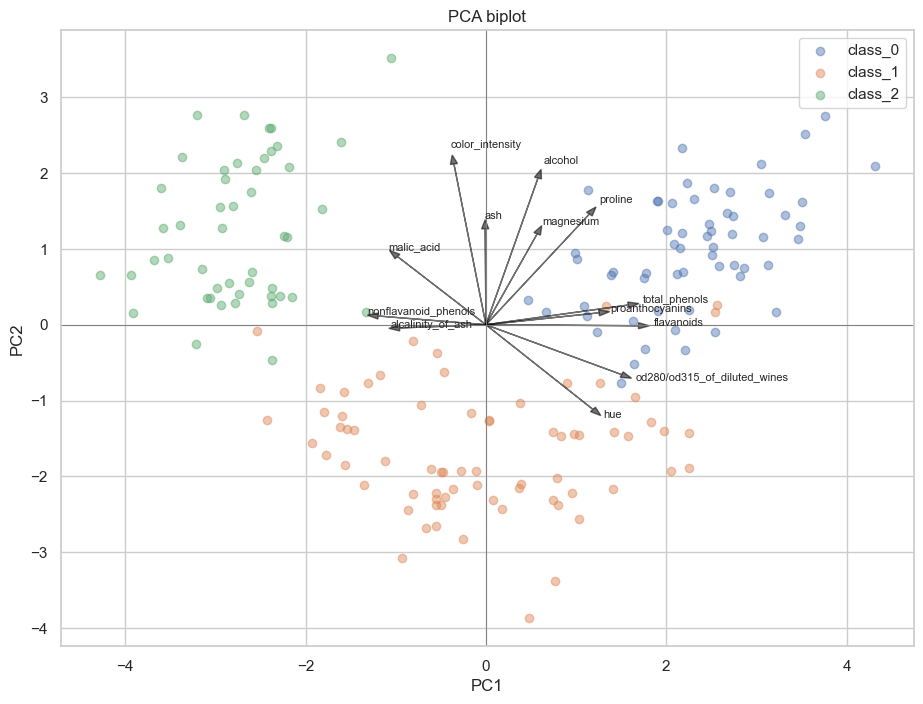

In [13]:
plt.figure(figsize=(11, 8))
for class_index, class_name in enumerate(dataset.target_names):
    mask = target == class_index
    plt.scatter(projection[mask, 0], projection[mask, 1], alpha=0.45, label=class_name)

scale = 4.0
for feature, row in loadings.iterrows():
    plt.arrow(0, 0, row["PC1"] * scale, row["PC2"] * scale, color="black", alpha=0.55, head_width=0.08)
    plt.text(row["PC1"] * scale * 1.1, row["PC2"] * scale * 1.1, feature, fontsize=8)
plt.axhline(0, color="gray", linewidth=0.7)
plt.axvline(0, color="gray", linewidth=0.7)
plt.title("PCA biplot")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

### Итог расширенного анализа

PCA чувствителен к масштабу признаков. Explained variance отвечает за сохранение информации, reconstruction error показывает потерю исходного пространства, а сравнение downstream-моделей проверяет, сохранилась ли полезная для классификации структура.